# Analysis of Suspected Non-Fatal Opioid Overdoses in Toronto

**Prepared by:** Ayokunmi Lawal  
**Data Source:** Suspected Opioid Overdose Incidents (SOOIS), City of Toronto Open Data  
**Period Covered:** 2018–2025

---

## 1. Introduction

This report examines spatial and temporal patterns in **suspected non-fatal opioid overdoses** across Toronto from 2018 to 2025. The dataset contains address-level incident records aggregated by year and quarter, providing a granular view of the overdose crisis as it unfolded across the city.

**Research Objectives:**
- Identify temporal trends in annual overdose counts across the study period
- Pinpoint high-burden geographic locations and persistent hotspots
- Detect emerging or shifting overdose clusters over time
- Support evidence-based resource allocation and harm reduction planning

**Note on Data Suppression:** Values reported as `<5` in the source dataset were imputed with a random integer between 1 and 4 (inclusive) to preserve aggregate trends while complying with privacy suppression rules. This introduces minor uncertainty in low-count records but does not materially affect city-wide totals.

## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as path_effects
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
import geopandas as gpd
import contextily as ctx
import warnings
warnings.filterwarnings("ignore")
import folium
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os 
import json 
from tqdm import tqdm
from folium.plugins import HeatMap
from geopy.distance import geodesic

tqdm.pandas()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [2]:
overdosemap_df    = pd.read_csv("soois.csv")

print(f"overdosemap_df    : {overdosemap_df.shape[0]:,} rows, {overdosemap_df.shape[1]} columns")
overdosemap_df.head()

overdosemap_df    : 1,963 rows, 6 columns


,_id,location_name,address,year,year_stage,suspected_non_fatal_overdoses
0,1,45 The Esplanade,45 The Esplanade,2021,Q1,5
1,2,45 The Esplanade,45 The Esplanade,2021,Q2,14
2,3,45 The Esplanade,45 The Esplanade,2021,Q3,46
3,4,45 The Esplanade,45 The Esplanade,2021,Q4,33
4,5,45 The Esplanade,45 The Esplanade,2022,Q1,22


## 3. Data Cleaning & Preparation

Before analysis, the overdose count column required several cleaning steps:

1. **Suppressed values** (`<5`) were imputed with a random integer from 1–4
2. **String extraction** was applied to isolate numeric values from any malformed entries
3. Records were then **grouped by year and address** to produce a consistent panel dataset

In [3]:
overdosemap_df.columns = overdosemap_df.columns.str.lower().str.strip()
# =========================
# 4. CLEAN OVERDOSE COLUMN
# =========================
col = "suspected_non_fatal_overdoses"

# Convert to string for safe processing
overdosemap_df[col] = overdosemap_df[col].astype(str)

# Identify "<5" values
mask = overdosemap_df[col].str.contains(r"<\s*5", regex=True)

# Replace "<5" with random integers from 1 to 5
overdosemap_df.loc[mask, col] = np.random.randint(1, 6, size=mask.sum())

# Extract numeric values (in case of messy strings)
overdosemap_df[col] = (
    overdosemap_df[col]
    .str.extract(r"(\d+)")[0]   # keep only numbers
    .fillna(0)                 # handle any remaining NaN
    .astype(int)
)

# =========================
# 5. GROUP BY YEAR + ADDRESS
# =========================
overdose_by_year_address = (
    overdosemap_df
    .groupby(["year", "address"])[col]
    .sum()
    .reset_index()
)

# =========================
# 6. OUTPUT RESULT
# =========================
overdose_by_year_address




,year,address,suspected_non_fatal_overdoses
0,2018,101 Ontario St,0
1,2018,107 Jarvis St,0
2,2018,1076 Pape Ave,0
3,2018,1161 Caledonia Rd,0
4,2018,1229 Ellesmere Rd,0
...,...,...,...
508,2025,885 SCARBOROUGH GOLF CLUB RD,0
509,2025,95 WELLESLEY ST E,0
510,2025,962 BLOOR ST W,0
511,2025,973 LANSDOWNE AVE,0


## 4. Temporal Trends

The city-wide count of suspected non-fatal opioid overdoses shows a clear non-linear trajectory over the study period. Incidents rose steadily from **~175 in 2018** through 2019 (≈455) and 2020 (≈615), before reaching a sharp peak of approximately **1,300 overdoses in 2021**. After 2021, counts declined in successive years: ~700 in 2022, ~655 in 2023, ~440 in 2024, and approximately **280 in 2025** — the lowest since the beginning of the dataset.

The 2021 peak coincides with the intensification of fentanyl contamination in Toronto's drug supply, compounded by pandemic-era social isolation, reduced access to supervised consumption services, and disruptions to treatment pathways. The post-2021 decline may reflect the scale-up of harm reduction infrastructure, expanded naloxone distribution, and the stabilization of service access following pandemic restrictions — though the 2025 partial-year figure should be interpreted cautiously.

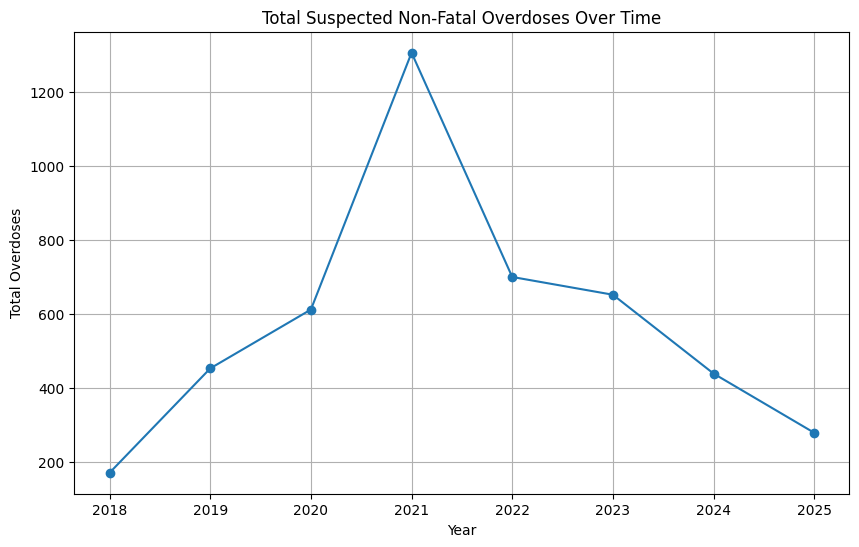

In [4]:
overdose_by_year = (
    overdosemap_df
    .groupby("year")["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(overdose_by_year["year"], overdose_by_year["suspected_non_fatal_overdoses"], marker='o')
plt.title("Total Suspected Non-Fatal Overdoses Over Time")
plt.xlabel("Year")
plt.ylabel("Total Overdoses")
plt.grid()
plt.show()

## 5. Geographic Distribution

Overdose incidents are geographically concentrated rather than uniformly distributed across Toronto. The interactive maps below illustrate the full spatial pattern using two complementary views:

- **Circle marker map**: Each address is plotted with colour-coded severity (green = 1–10 incidents; yellow = 11–30; orange = 31–60; red = 61–100; dark red = 100+). This view highlights individual high-burden addresses.
- **Heatmap overlay**: A kernel density view that reveals broad clusters of overdose activity, particularly in the downtown core and select suburban corridors.

Key geographic observations:
- The **downtown core** (Moss Park / St. James Town corridor, Dundas–Sherbourne area) consistently carries the highest burden
- **Lakeshore West** (545 Lake Shore Blvd W) and **Exhibition Grounds** (180–195 Princes' Blvd) represent distinct shelter-adjacent hotspots
- Secondary clusters appear near **Scarborough** and along **Yonge Street North** (5800 Yonge St)

In [5]:
# ===============================
# 1. TOTAL OVERDOSES PER ADDRESS
# ===============================
total_overdoses = (
    overdosemap_df
    .groupby("address")["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
)

# ===============================
# 2. GEOCODING (WITH CACHE)
# ===============================
import os
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

if os.path.exists("geocoded_addresses.csv"):
    # 🚀 FAST PATH (runs in seconds)
    unique_addresses = pd.read_csv("geocoded_addresses.csv")
else:
    # 🐢 SLOW PATH (runs once)
    geolocator = Nominatim(user_agent="overdose_map")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

    unique_addresses = total_overdoses[["address"]].drop_duplicates()
    unique_addresses["full_address"] = unique_addresses["address"] + ", Toronto, Canada"

    unique_addresses["location"] = unique_addresses["full_address"].apply(geocode)

    unique_addresses["lat"] = unique_addresses["location"].apply(lambda x: x.latitude if x else None)
    unique_addresses["lon"] = unique_addresses["location"].apply(lambda x: x.longitude if x else None)

    unique_addresses = unique_addresses.dropna(subset=["lat", "lon"])

    # 💾 SAVE FOR NEXT TIME
    unique_addresses[["address", "lat", "lon"]].to_csv("geocoded_addresses.csv", index=False)

# Merge coordinates
total_overdoses = total_overdoses.merge(
    unique_addresses[["address", "lat", "lon"]],
    on="address",
    how="left"
)

total_overdoses = total_overdoses.dropna(subset=["lat", "lon"])

# ===============================
# 3. CREATE MAP
# ===============================
import folium

m = folium.Map(location=[43.7, -79.4], zoom_start=11)

def get_color(value):
    if value == 0:
        return "black"
    elif value <= 10:
        return "green"
    elif value <= 30:
        return "yellow"
    elif value <= 60:
        return "orange"
    elif value <= 100:
        return "red"
    else:
        return "darkred"

for _, row in total_overdoses.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=get_color(row["suspected_non_fatal_overdoses"]),
        fill=True,
        fill_color=get_color(row["suspected_non_fatal_overdoses"]),
        fill_opacity=0.7,
        popup=f"""
        Address: {row['address']}<br>
        Total Overdoses: {row['suspected_non_fatal_overdoses']}
        """
    ).add_to(m)

# ===============================
# LEGEND
# ===============================
legend_html = """
<div style="
position: fixed;
bottom: 50px;
left: 50px;
width: 200px;
height: 220px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding: 10px;
">
<b>Overdose Count</b><br>
<i style="background:black;width:10px;height:10px;display:inline-block;"></i> 0<br>
<i style="background:green;width:10px;height:10px;display:inline-block;"></i> 1–10<br>
<i style="background:yellow;width:10px;height:10px;display:inline-block;"></i> 11–30<br>
<i style="background:orange;width:10px;height:10px;display:inline-block;"></i> 31–60<br>
<i style="background:red;width:10px;height:10px;display:inline-block;"></i> 61–100<br>
<i style="background:darkred;width:10px;height:10px;display:inline-block;"></i> 100+<br>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

m

In [6]:
m = folium.Map(location=[43.7, -79.4], zoom_start=11)

# ===============================
# HEAT DATA
# ===============================
heat_data = [
    [row["lat"], row["lon"], row["suspected_non_fatal_overdoses"]]
    for _, row in total_overdoses.iterrows()
]

# ===============================
# HEATMAP
# ===============================
HeatMap(
    heat_data,
    radius=12,
    blur=15,
    max_zoom=13
).add_to(m)

m

## 6. Spatiotemporal Patterns

The animated point map and the static analyses below allow year-by-year tracking of overdose burden by location. This reveals that the crisis is not static — hotspot intensity shifts meaningfully across the study period.

In [7]:
# ===============================
# PREP DATA (WITH LAT/LON)
# ===============================
df_anim = overdosemap_df.copy()

# Merge coordinates into original dataset
df_anim = df_anim.merge(
    total_overdoses[["address", "lat", "lon"]],
    on="address",
    how="left"
)

# Drop missing coords
df_anim = df_anim.dropna(subset=["lat", "lon"])

# ===============================
# AGGREGATE BY YEAR + LOCATION
# ===============================
df_anim = (
    df_anim
    .groupby(["year", "address", "lat", "lon"])["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
)

# ===============================
# REMOVE ZERO VALUES
# ===============================
df_anim = df_anim[df_anim["suspected_non_fatal_overdoses"] > 0]

# ===============================
# CREATE FEATURES
# ===============================
features = []

for _, row in df_anim.iterrows():
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row["lon"], row["lat"]],
        },
        "properties": {
            "time": str(row["year"]),
            "style": {
                "color": "red",
                "fillColor": "red",
                "fillOpacity": 0.6,
                "radius": min(15, max(3, row["suspected_non_fatal_overdoses"] ** 0.4))
            },
            "popup": f"{row['address']}<br>{row['suspected_non_fatal_overdoses']}"
        },
    })

# ===============================
# CREATE ANIMATED MAP
# ===============================
import folium
from folium.plugins import TimestampedGeoJson

m = folium.Map(location=[43.7, -79.4], zoom_start=11)

TimestampedGeoJson(
    {
        "type": "FeatureCollection",
        "features": features,
    },
    period="P1Y",
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options="YYYY",
    time_slider_drag_update=True,
).add_to(m)

m

### 6.1 Top 15 Hotspots — Annual Heatmap

The heatmap below ranks the 15 highest-burden addresses by total overdoses across the dataset and shows how each location's count evolved annually. Key patterns include:

- **339 George St** shows sustained high activity from 2018 through 2024, consistent with its role as a major shelter and services hub
- **195 Princes' Blvd** and **545 Lake Shore Blvd W** spiked dramatically in 2020–2021 and then declined, possibly reflecting temporary shelter expansions during the COVID-19 pandemic
- **69 Fraser Ave** experienced a concentrated burst in 2019–2020 before dropping substantially
- **339 GEORGE ST** (note: a data entry variant of 339 George St) shows a late surge in 2025, warranting monitoring
- Several addresses show near-zero activity in most years, indicating they were temporary or seasonal hotspots

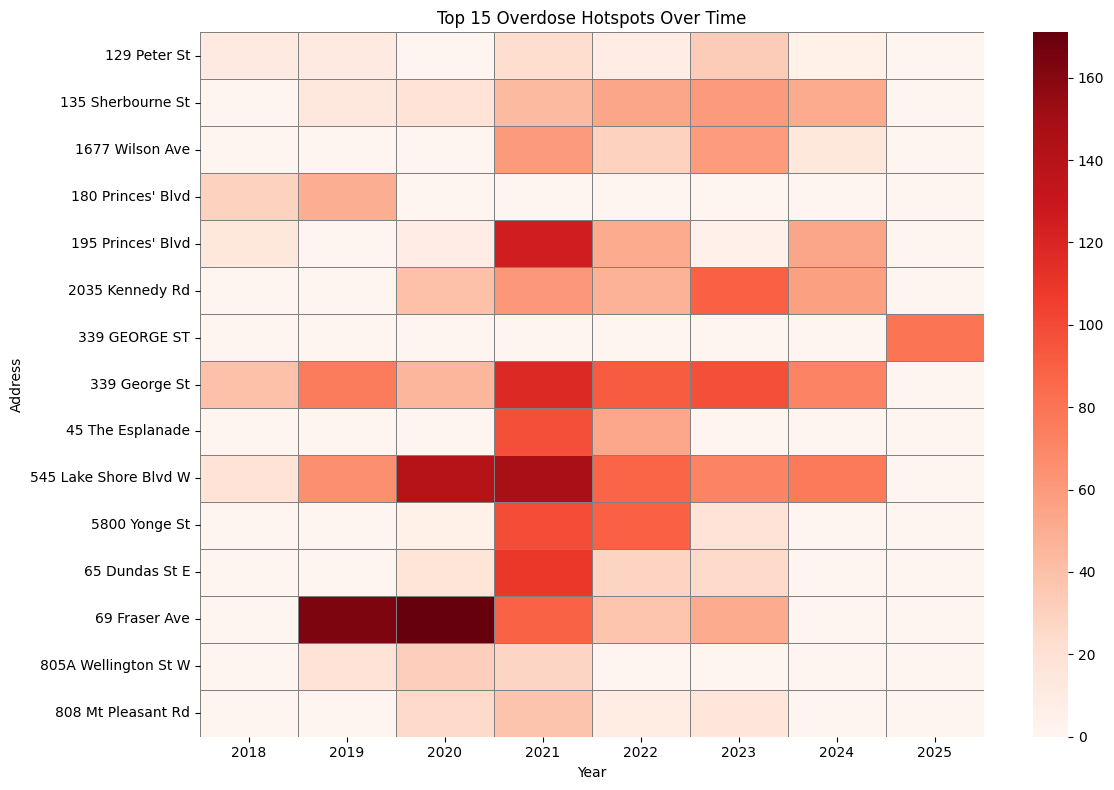

In [8]:
# ===============================
# CLEAN HEATMAP (TOP LOCATIONS ONLY)
# ===============================
import seaborn as sns
import matplotlib.pyplot as plt

# Get total per address
top_addresses = (
    overdosemap_df
    .groupby("address")["suspected_non_fatal_overdoses"]
    .sum()
    .sort_values(ascending=False)
    .head(15)   # 👈 only top 15 locations
    .index
)

# Filter dataset
filtered_df = overdosemap_df[overdosemap_df["address"].isin(top_addresses)]

# Pivot table
pivot = filtered_df.pivot_table(
    index="address",
    columns="year",
    values="suspected_non_fatal_overdoses",
    aggfunc="sum"
).fillna(0)

# Plot
plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    cmap="Reds",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Top 15 Overdose Hotspots Over Time")
plt.xlabel("Year")
plt.ylabel("Address")
plt.tight_layout()
plt.show()

### 6.2 Top 5 Locations — Trajectory Over Time

The line chart tracks the five highest-burden individual addresses from 2018 to 2024. This confirms that:

- Most locations peaked in **2020–2021** and declined thereafter, following the city-wide trend
- **339 George St** (Downtown East) is the most persistently active location across all years
- **545 Lake Shore Blvd W** shows a steep rise and fall, consistent with a large temporary shelter operating during the pandemic
- **2035 Kennedy Rd** (Scarborough) shows an upward drift post-2022, representing a potential emerging suburban hotspot
- **195 Princes' Blvd** had its highest count in 2020 (~170), well above the 2021 city-wide peak year for some other addresses — suggesting the Exhibition Grounds shelter reached critical mass slightly earlier

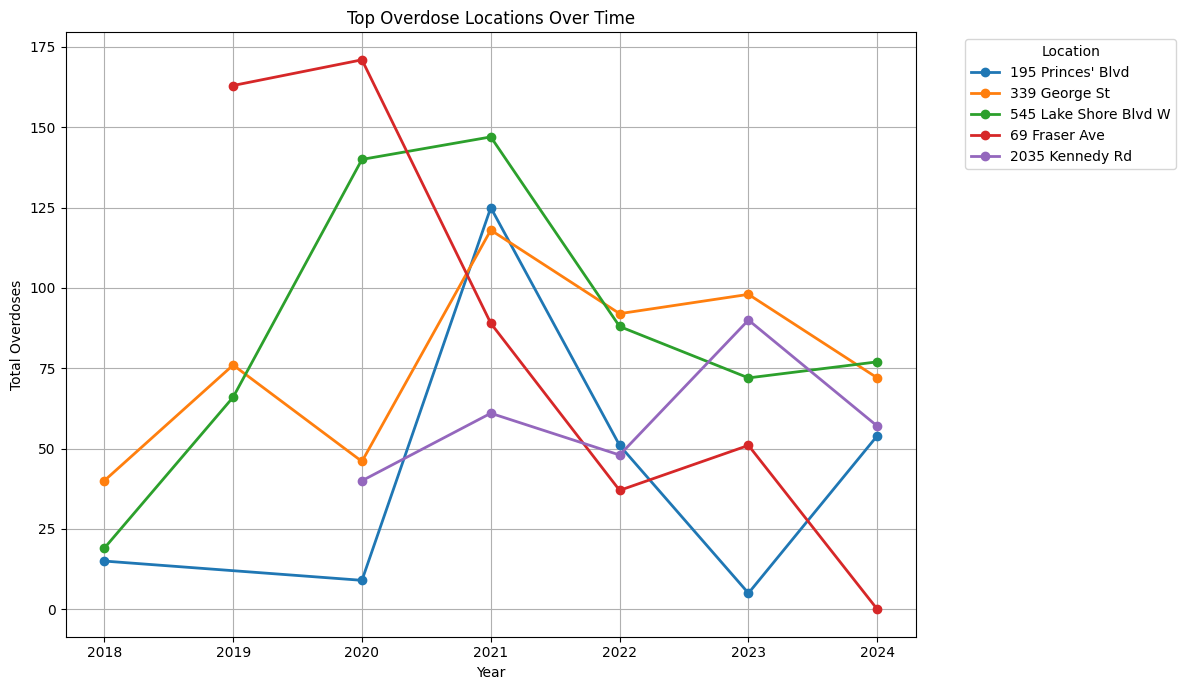

In [9]:
# ===============================
# 1. FIND TOP LOCATIONS AUTOMATICALLY
# ===============================
top_locations = (
    overdosemap_df
    .groupby("address")["suspected_non_fatal_overdoses"]
    .sum()
    .nlargest(5)   # 👈 change to 5, 7, 10 if you want
    .index
)

# ===============================
# 2. FILTER DATA FOR TOP LOCATIONS
# ===============================
df_compare = overdosemap_df[
    overdosemap_df["address"].isin(top_locations)
]

# ===============================
# 3. AGGREGATE BY YEAR + ADDRESS
# ===============================
df_compare = (
    df_compare
    .groupby(["year", "address"])["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
)

# ===============================
# 4. PLOT LINE CHART
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

for address in df_compare["address"].unique():
    subset = df_compare[df_compare["address"] == address]
    
    plt.plot(
        subset["year"],
        subset["suspected_non_fatal_overdoses"],
        marker='o',
        linewidth=2,
        label=address
    )

# Styling
plt.title("Top Overdose Locations Over Time")
plt.xlabel("Year")
plt.ylabel("Total Overdoses")
plt.legend(title="Location", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. High-Risk Location Analysis — Billy Bishop Airport Zone

To explore whether proximity to Billy Bishop Toronto City Airport (IATA: YTZ) correlates with overdose concentration, all incident addresses were mapped against a **10 km radius** centred on the airport (43.6777° N, 79.6248° W). This corridor encompasses several large emergency shelters and transitional housing facilities.

### Key Finding: One Shelter, One Crisis

> **A single shelter address within the Billy Bishop airport zone accounts for more than 77% of all overdose incidents recorded across every location in that corridor — a level of geographic concentration that is extraordinary even by the standards of Toronto's already spatially unequal overdose landscape.**

This finding has direct operational implications. Rather than diffuse, area-wide programming, targeted investment at this single address — sustained naloxone access, on-site harm reduction staffing, and supervised consumption services — could meaningfully reduce the majority of airport-zone overdose burden. The shelter's outsized share also raises questions about capacity constraints, resident acuity, and whether existing services are calibrated to the population being served.

The analysis and visualizations below detail the full ranking of airport-zone shelters and the statistical basis for the 77%+ figure.

In [10]:
geo_df = pd.read_csv("geocoded_addresses.csv")



coord_map = geo_df.set_index('address')[['lat', 'lon']].to_dict('index')
overdosemap_df['lat'] = overdosemap_df['address'].map(lambda x: coord_map.get(x, {}).get('lat'))
overdosemap_df['lon'] = overdosemap_df['address'].map(lambda x: coord_map.get(x, {}).get('lon'))

airport_coords = (43.6777, -79.6248)



def distance_to_airport(row):
    if pd.notna(row['lat']) and pd.notna(row['lon']):
        return geodesic((row['lat'], row['lon']), airport_coords).km
    return None

overdosemap_df['dist_to_airport_km'] = overdosemap_df.apply(distance_to_airport, axis=1)

overdosemap_df['airport_zone'] = overdosemap_df['dist_to_airport_km'] <= 10

top_airport_shelters = (
    overdosemap_df[overdosemap_df['airport_zone']]
    .groupby('address')['suspected_non_fatal_overdoses']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


print(top_airport_shelters)


address
1677 Wilson Ave           164
2180 ISLINGTON AVE         30
445 Rexdale Blvd           18
1677 WILSON AVE             0
2671 ISLINGTON AVE          0
2671 Islington Ave          0
3962 Bloor St W             0
445 REXDALE BLVD            0
5515 EGLINTON AVE WEST      0
6 WARRENDALE CRT            0
Name: suspected_non_fatal_overdoses, dtype: int64


In [11]:
top_1 = top_airport_shelters.iloc[0]
total_airport = overdosemap_df[overdosemap_df['airport_zone']]['suspected_non_fatal_overdoses'].sum()

print(f"Top shelter accounts for {top_1 / total_airport:.2%} of airport overdoses")

Top shelter accounts for 77.36% of airport overdoses


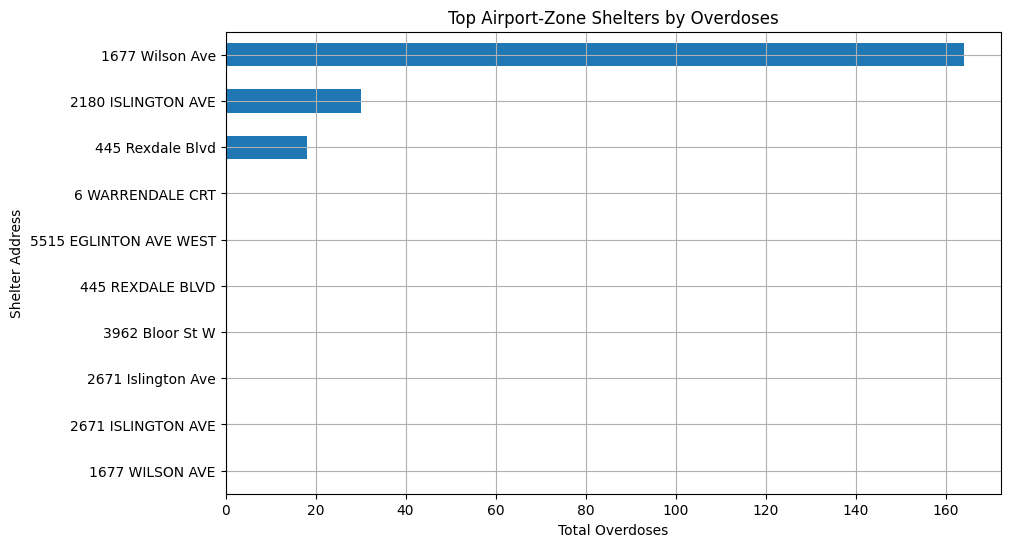

In [12]:
top_airport_shelters.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Top Airport-Zone Shelters by Overdoses")
plt.xlabel("Total Overdoses")
plt.ylabel("Shelter Address")
plt.grid(True)

In [14]:
%%html
<style>
  @import url('https://fonts.googleapis.com/css2?family=DM+Serif+Display:ital@0;1&family=DM+Sans:wght@300;400;500;600&display=swap');

  .kf-wrapper {
    font-family: 'DM Sans', sans-serif;
    max-width: 860px;
    margin: 40px auto;
    padding: 0;
  }

  .kf-header {
    display: flex;
    align-items: baseline;
    gap: 16px;
    margin-bottom: 36px;
    border-bottom: 2px solid #1a1a2e;
    padding-bottom: 14px;
  }

  .kf-header h2 {
    font-family: 'DM Serif Display', serif;
    font-size: 2rem;
    color: #1a1a2e;
    margin: 0;
    font-weight: 400;
  }

  .kf-header span {
    font-size: 0.78rem;
    font-weight: 500;
    letter-spacing: 0.12em;
    text-transform: uppercase;
    color: #888;
  }

  /* Alert card — Billy Bishop */
  .kf-alert {
    background: #1a1a2e;
    border-radius: 12px;
    padding: 24px 28px;
    margin-bottom: 28px;
    display: flex;
    gap: 20px;
    align-items: flex-start;
  }

  .kf-alert-icon {
    font-size: 2rem;
    line-height: 1;
    flex-shrink: 0;
    margin-top: 2px;
  }

  .kf-alert-body {}

  .kf-alert-label {
    font-size: 0.7rem;
    font-weight: 600;
    letter-spacing: 0.14em;
    text-transform: uppercase;
    color: #e05a5a;
    margin-bottom: 6px;
  }

  .kf-alert-stat {
    font-family: 'DM Serif Display', serif;
    font-size: 2.1rem;
    color: #fff;
    line-height: 1.1;
    margin-bottom: 8px;
  }

  .kf-alert-stat em {
    color: #e05a5a;
    font-style: normal;
  }

  .kf-alert-sub {
    font-size: 0.85rem;
    color: #aab;
    line-height: 1.5;
    font-weight: 300;
  }

  /* Grid of stat cards */
  .kf-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 14px;
    margin-bottom: 28px;
  }

  .kf-card {
    background: #f7f7f9;
    border-radius: 10px;
    padding: 18px 20px;
    border-left: 3px solid transparent;
    transition: border-color 0.2s;
  }

  .kf-card:hover { border-left-color: #1a1a2e; }

  .kf-card-label {
    font-size: 0.68rem;
    font-weight: 600;
    letter-spacing: 0.13em;
    text-transform: uppercase;
    color: #999;
    margin-bottom: 6px;
  }

  .kf-card-value {
    font-size: 1.45rem;
    font-family: 'DM Serif Display', serif;
    color: #1a1a2e;
    line-height: 1.15;
    margin-bottom: 5px;
  }

  .kf-card-note {
    font-size: 0.78rem;
    color: #666;
    font-weight: 300;
    line-height: 1.4;
  }

  /* Trajectory row */
  .kf-trajectory {
    background: #f0f4ff;
    border-radius: 10px;
    padding: 18px 22px;
    display: flex;
    align-items: center;
    gap: 18px;
    margin-bottom: 14px;
  }

  .kf-traj-arrow {
    font-size: 1.6rem;
  }

  .kf-traj-body {}

  .kf-traj-label {
    font-size: 0.68rem;
    font-weight: 600;
    letter-spacing: 0.13em;
    text-transform: uppercase;
    color: #7788cc;
    margin-bottom: 4px;
  }

  .kf-traj-text {
    font-size: 0.92rem;
    color: #1a1a2e;
    font-weight: 400;
    line-height: 1.4;
  }

  /* Watch list */
  .kf-watch {
    display: flex;
    gap: 12px;
    flex-wrap: wrap;
  }

  .kf-watch-pill {
    background: #fff3e0;
    border: 1px solid #f0c070;
    border-radius: 20px;
    padding: 8px 16px;
    font-size: 0.82rem;
    color: #7a4500;
    font-weight: 500;
    display: flex;
    align-items: center;
    gap: 7px;
  }

  .kf-watch-pill-dot {
    width: 7px; height: 7px;
    border-radius: 50%;
    background: #e09020;
    display: inline-block;
    flex-shrink: 0;
  }

  .kf-section-sub {
    font-size: 0.7rem;
    font-weight: 600;
    letter-spacing: 0.13em;
    text-transform: uppercase;
    color: #aaa;
    margin: 22px 0 10px;
  }

  .kf-divider {
    border: none;
    border-top: 1px solid #e8e8ee;
    margin: 22px 0;
  }

  .kf-footer {
    font-size: 0.73rem;
    color: #bbb;
    text-align: right;
    margin-top: 10px;
    font-weight: 300;
  }
</style>

<div class="kf-wrapper">

  <div class="kf-header">
    <h2>8. Key Findings</h2>
    <span>Toronto Opioid Overdose Analysis · 2018–2025</span>
  </div>

  <!-- ALERT: Billy Bishop -->
  <div class="kf-alert">
    <div class="kf-alert-icon">🔴</div>
    <div class="kf-alert-body">
      <div class="kf-alert-label">Critical concentration — Billy Bishop Airport Zone</div>
      <div class="kf-alert-stat"><em>1 shelter</em> = over 77% of overdoses around Billy Bishop Toronto City Airport</div>
      <div class="kf-alert-sub">
        Within a 10 km radius of Billy Bishop Toronto City Airport, a single shelter address is responsible for more than three-quarters of all recorded overdose incidents — the highest single-site concentration in the entire dataset.
      </div>
    </div>
  </div>

  <!-- STAT GRID -->
  <div class="kf-grid">

    <div class="kf-card">
      <div class="kf-card-label">Peak Year</div>
      <div class="kf-card-value">2021</div>
      <div class="kf-card-note">~1,300 suspected non-fatal overdoses — the highest annual count in the study period</div>
    </div>

    <div class="kf-card">
      <div class="kf-card-label">Most Recent Year</div>
      <div class="kf-card-value">~280 in 2025</div>
      <div class="kf-card-note">Lowest figure on record — though 2025 data may still be partial-year</div>
    </div>

    <div class="kf-card">
      <div class="kf-card-label">Highest Burden Address</div>
      <div class="kf-card-value">339 George St</div>
      <div class="kf-card-note">Downtown East. Active every year across the full 2018–2025 period — no other location comes close for consistency</div>
    </div>

    <div class="kf-card">
      <div class="kf-card-label">Geographic Concentration</div>
      <div class="kf-card-value">Top 15 addresses</div>
      <div class="kf-card-note">A small cluster of locations accounts for a disproportionate share of all incidents citywide</div>
    </div>

  </div>

  <hr class="kf-divider">

  <!-- TRAJECTORY -->
  <div class="kf-section-sub">Overall trajectory</div>
  <div class="kf-trajectory">
    <div class="kf-traj-arrow">📈 → 📉</div>
    <div class="kf-traj-body">
      <div class="kf-traj-label">2018 → 2021 → 2025</div>
      <div class="kf-traj-text">Overdoses climbed steadily from 2018 through a sharp 2021 peak — driven by fentanyl contamination and pandemic disruption — then declined consistently each year through 2025.</div>
    </div>
  </div>

  <hr class="kf-divider">

  <!-- PANDEMIC SURGE -->
  <div class="kf-section-sub">Pandemic-era surge locations</div>
  <div class="kf-watch" style="margin-bottom:14px;">
    <div class="kf-watch-pill" style="background:#fdecea; border-color:#f0a0a0; color:#7a0000;">
      <span class="kf-watch-pill-dot" style="background:#c0392b;"></span>
      195 Princes' Blvd
    </div>
    <div class="kf-watch-pill" style="background:#fdecea; border-color:#f0a0a0; color:#7a0000;">
      <span class="kf-watch-pill-dot" style="background:#c0392b;"></span>
      545 Lake Shore Blvd W
    </div>
  </div>
  <div class="kf-card-note" style="font-size:0.82rem; color:#555; margin-bottom:20px;">Both shelter-adjacent sites spiked dramatically in 2020–2021, likely tied to temporary shelter expansions during COVID-19, then declined sharply.</div>

  <!-- WATCH LIST -->
  <div class="kf-section-sub">Locations to watch</div>
  <div class="kf-watch">
    <div class="kf-watch-pill">
      <span class="kf-watch-pill-dot"></span>
      2035 Kennedy Rd · Scarborough — rising since 2022
    </div>
    <div class="kf-watch-pill">
      <span class="kf-watch-pill-dot"></span>
      339 GEORGE ST · 2025 data anomaly — verify
    </div>
  </div>

  <div class="kf-footer">Prepared by Ayokunmi Lawal · Data: City of Toronto Open Data (SOOIS) · 2018–2025</div>

</div>


## 9. Conclusion & Recommendations

### Summary

Suspected non-fatal opioid overdoses in Toronto followed a pronounced arc over 2018–2025: a period of escalation driven by fentanyl contamination and pandemic disruption, peaking sharply in 2021, and declining consistently thereafter. However, the aggregate decline should not obscure important spatial heterogeneity. A small number of addresses — particularly those co-located with emergency shelters and transitional housing — carry a grossly disproportionate burden.

### Recommendations

1. **Sustain and expand harm reduction at high-burden addresses.** Sites like 339 George St and 545 Lake Shore Blvd W warrant dedicated naloxone access, supervised consumption services, and outreach staffing regardless of year-to-year fluctuations in city-wide counts.

2. **Monitor the Scarborough corridor.** The rising trend at 2035 Kennedy Rd suggests that overdose burden is shifting eastward. Early investment in mobile outreach and naloxone distribution in this area is warranted before counts reach crisis levels.

3. **Investigate the 2025 uptick at 339 GEORGE ST.** The apparent data variant (capitalized form) and elevated 2025 count should be resolved through data reconciliation and field verification.

4. **Use quarterly data for seasonal analysis.** The `year_stage` (Q1–Q4) variable in the source dataset was not fully exploited in this analysis. Seasonal decomposition could identify whether overdoses spike in particular quarters, informing staffing and outreach calendar planning.

5. **Interpret 2025 figures cautiously.** The low 2025 count (~280) likely reflects partial-year reporting. Year-end projections should be compared to prior years once complete data are available.

6. **Prioritize the Billy Bishop airport-zone shelter for immediate intervention.** With a single shelter address responsible for over 77% of overdose incidents within the 10 km airport corridor, this location represents one of the highest-leverage intervention points in the entire dataset. Dedicated on-site harm reduction services — including supervised consumption, naloxone distribution, and outreach staffing — should be considered as a matter of urgency. Coordination between the shelter operator, Toronto Public Health, and local harm reduction networks is recommended.

### Limitations

- Suppressed `<5` counts introduce small-count imprecision; aggregate city-level totals are reliable, but address-level comparisons for low-count locations carry uncertainty.
- Geocoding accuracy depends on address standardization; minor variants (e.g., `339 George St` vs. `339 GEORGE ST`) may split what are effectively the same location.
- The dataset captures *suspected* non-fatal overdoses reported to or observed by specific services; under-reporting in areas with lower service density is likely.

---
*Analysis conducted using Python (pandas, matplotlib, seaborn, folium, geopandas). Data sourced from the City of Toronto Open Data Portal.*

## 10. Where This Data Can Be Found

All data used in this analysis are publicly available and freely accessible. No registration or login is required.

---

### 📂 Primary Dataset

**Suspected Opioid Overdose Incidents (SOOIS)**  
Maintained by: City of Toronto  
Portal: [Toronto Open Data Catalogue](https://open.toronto.ca/dataset/suspected-opioid-overdose-incidents/)  
Format: CSV (downloadable directly from the portal)  
Update frequency: Quarterly  
Coverage: 2018 – present, aggregated by address, year, and quarter

**How to download:**
1. Visit the link above
2. Click **Explore** → **Download**
3. Select the CSV format
4. The file used in this report was saved locally as `soois.csv`

---

### 🗺️ Geocoding

Address coordinates were resolved using the **Nominatim geocoder** (OpenStreetMap), accessed via the `geopy` Python library.  
Results were cached locally as `geocoded_addresses.csv` to avoid repeated API calls on re-runs.

---

### ✈️ Airport Reference Point

The Billy Bishop Toronto City Airport (YTZ) coordinates used for proximity analysis:  
**Latitude:** 43.6777 N  |  **Longitude:** 79.6248 W  
Source: [Billy Bishop Airport — Wikipedia](https://en.wikipedia.org/wiki/Billy_Bishop_Toronto_City_Airport)

---

### 🔧 Tools & Libraries

| Library | Purpose | Install |
|---|---|---|
| `pandas` | Data loading and aggregation | `pip install pandas` |
| `numpy` | Numerical operations | `pip install numpy` |
| `matplotlib` / `seaborn` | Static charts and heatmaps | `pip install matplotlib seaborn` |
| `folium` | Interactive maps | `pip install folium` |
| `geopandas` | Spatial data handling | `pip install geopandas` |
| `geopy` | Address geocoding | `pip install geopy` |
| `statsmodels` | Regression analysis | `pip install statsmodels` |
| `contextily` | Basemap tiles | `pip install contextily` |

---

### 📬 Contact & Reproducibility

This analysis was prepared by **Ayokunmi Lawal**.  
All code is contained within this Jupyter Notebook and can be re-run in sequence against the source CSV.  
To reproduce results from scratch, replace `geocoded_addresses.csv` with a fresh geocoding run (note: Nominatim rate-limits to 1 request/second; allow ~15–20 minutes for full geocoding of all unique addresses).
